# Nuova nuova versione dell'interfaccia

In [25]:
from serial.tools import list_ports
import sys
import os
from src.lib.new_drivers import Bilancia, Camera
from matplotlib import pyplot as plt
import matplotlib.patches as pa
import ipywidgets as widgets
from collections import deque
import ipywidgets as widgets
from matplotlib import pyplot as plt
import os
import time
import numpy as np
from math import sqrt

In [26]:
%matplotlib widget
plt.close('all')

In [27]:
class BaseInterface:
    def __init__(self):
        self.fig = None
        self.axes = None
        self.update_timer = None
        self.widgets = {}
        self.artists = None

        self.output = widgets.Output()
    
    def _init_plot(self, suptitle, ncols, nrows, plot_types, plot_titles=None, xlabels=None, ylabels=None):
        with plt.ioff():

            self.fig, self.axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(8*ncols, 6*nrows))
            
            self.fig.suptitle(suptitle)
            
            if ncols == 1 and nrows == 1:
                self.axes = np.array([[self.axes]])
            elif ncols == 1:
                self.axes = self.axes[:, np.newaxis]
            elif nrows == 1:
                self.axes = self.axes[np.newaxis, :]
            
            self.artists = np.empty((nrows, ncols), dtype=object)
            for i in range(nrows):
                for j in range(ncols):
                    plot_type = plot_types[i][j]
                    if plot_type == 'image':
                        self.artists[i, j] = self.axes[i, j].imshow(np.zeros((10, 10)), cmap='gray')
                        self.axes[i, j].set_aspect('equal')
                    elif plot_type == 'line':
                        self.artists[i, j], = self.axes[i, j].plot([], [])
                    elif plot_type == 'scatter':
                        self.artists[i, j] = self.axes[i, j].scatter([], [])
                    
                    if plot_titles is not None:
                        self.axes[i, j].set_title(plot_titles[i][j])
                    if xlabels is not None and ylabels is not None:
                        self.axes[i, j].set_xlabel(xlabels[i][j])
                        self.axes[i, j].set_ylabel(ylabels[i][j])

    def _start_update_plot(self, interval=100):
        self.update_timer = self.fig.canvas.new_timer(interval=interval)
        self.update_timer.add_callback(self._update_plot)
        self.update_timer.start()
    
    def _stop_update_plot(self):
        if self.update_timer is not None:
            self.update_timer.stop()
            self.update_timer = None
        
    def _set_lims(self, lims, plot_types):
        for i in range(len(self.axes)):
            for j in range(len(self.axes[i])):

                if plot_types[i][j] is None:
                    continue
                
                if plot_types[i][j] == 'image':
                    self.axes[i, j].set_clim(*lims[i][j])

                if plot_types[i][j] in ['line', 'scatter']:
                    self.axes[i, j].set_xlim(lims[i][j][0])
                    self.axes[i, j].set_ylim(lims[i][j][1])
    
    def _set_lim(self, lim, plot_type, i, j):
        if plot_type is None:
            return
        
        if plot_type == 'image':
            self.axes[i, j].set_clim(*lim)

        if plot_type in ['line', 'scatter']:
            self.axes[i, j].set_xlim(lim[0])
            self.axes[i, j].set_ylim(lim[1])
    
    def _update_plot(self):
        pass
            


Output()

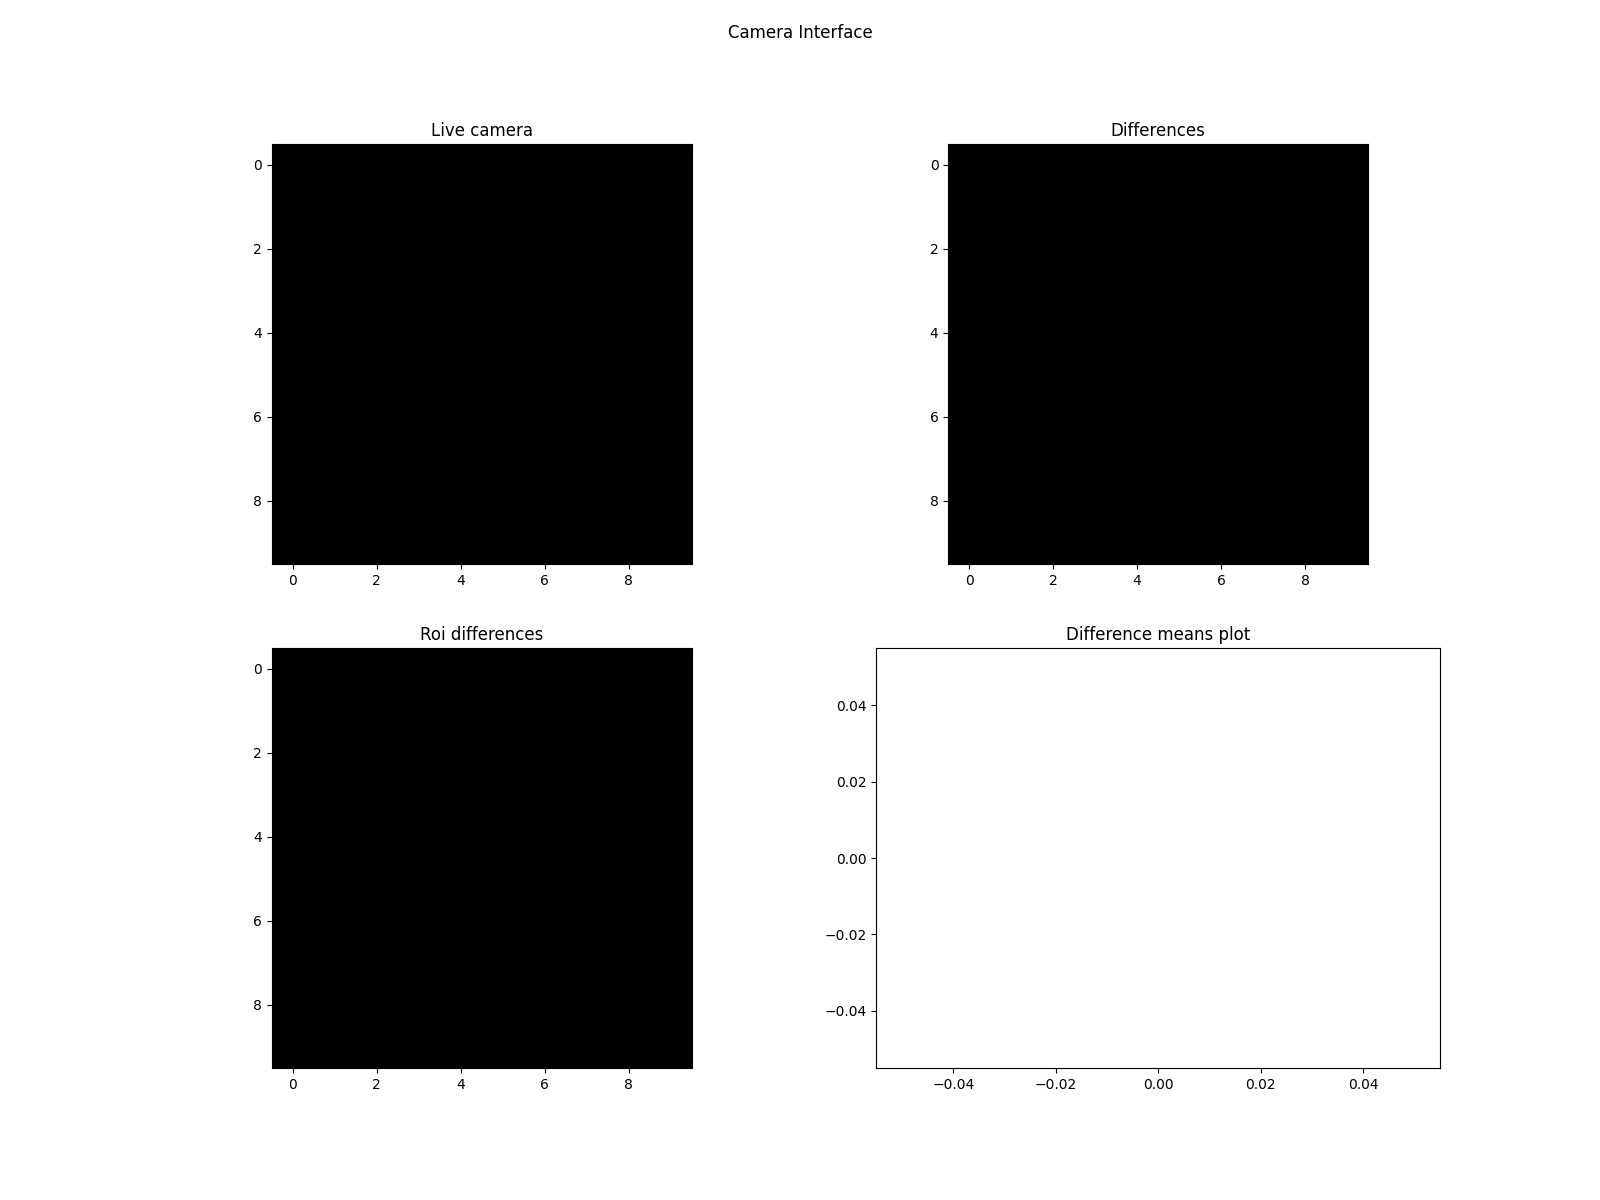

In [28]:
class CameraInterface(BaseInterface):
    def __init__(self, camera_index=0):
        super().__init__()

        self.frames = []
        self.reference_image = None

        self.roi_center = (350, 250)
        self.roi_radius = 50
        self.roi_patch = None

        self.camera = None

        self.means = []

        self.camera_index = camera_index

        self.widgets["start_btn"] = widgets.Button(description="Start Camera")
        self.widgets["stop_btn"] = widgets.Button(description="Stop Camera")
        self.widgets["reset_means_btn"] = widgets.Button(description="Reset Means")
        self.widgets["camera_select"] = widgets.Dropdown(options=range(10), description="Camera:")

        self._init_plot(
            suptitle="Camera Interface",
            ncols=2,
            nrows=2,
            plot_types=[['image', "image"], ["image", "line"]],
            plot_titles=[['Live camera', 'Differences'], ['Roi differences', "Difference means plot"]],
        )

        self.widgets["start_btn"].on_click(lambda _: self.on_start_btn())
        self.widgets["stop_btn"].on_click(lambda _: self.on_stop_btn())
        self.widgets["reset_means_btn"].on_click(lambda _: self.on_reset_means_btn())
        self.widgets["camera_select"].observe(lambda change: setattr(self, "camera_index", change['new']), names='value')

        self.fig.canvas.mpl_connect('button_press_event', self.on_roi_click)

        self.show()

    def show(self):
        display(self.output)
        display(widgets.HBox([self.widgets["start_btn"], self.widgets["stop_btn"], self.widgets["reset_means_btn"], self.widgets["camera_select"]]))
        display(self.fig.canvas)
    
    def connect_camera(self):
        try:
            self.camera = Camera(self.camera_index, keep_frames=1)
            if self.camera.cap.isOpened():
                with self.output:
                    print("Camera connessa con successo!")
            else:
                with self.output:
                    print("Impossibile aprire la camera.")
                raise Exception("Camera non aperta")
        
        except Exception as e:
            with self.output:
                print(f"Errore durante la connessione alla camera: {e}")
            
            self.camera = None
            return
    
    def on_reset_means_btn(self):
        self.means.clear()
        with self.output:
            print("Means reset.")

    def on_start_btn(self):
        with self.output:
            print("Starting camera...")
            
        self.connect_camera()
        self.camera._acquire_reference_image()
        self.reference_image = self.camera.im0
        self.camera.start_acquisition(center_x=320, center_y=240, radius=100, interval=0.1)

        self.camera.update_roi(self.roi_center[0], self.roi_center[1], self.roi_radius)

        self._start_update_plot(interval=50)


        # forse meglio annche svuotare i frame

    def on_stop_btn(self):
        if self.camera is not None:
            self.camera.stop_acquisition()
            self.camera.release()
            self.camera = None
            with self.output:
                print("Camera stopped.")
        else:
            with self.output:
                print("No camera to stop.")
        
        if self.update_timer is not None:
            self._stop_update_plot()
    
    def on_roi_click(self, event):
        if event.inaxes != self.axes[0, 0]:
            return
        
        # se tasto sinistro, cambia il centro
        if event.button == 1:
            self.roi_center = (int(event.xdata), int(event.ydata))
        
        # se tasto destro, cambia il raggio
        elif event.button == 3:
            dx = event.xdata - self.roi_center[0]
            dy = event.ydata - self.roi_center[1]
            self.roi_radius = int(sqrt(dx**2 + dy**2))
        
        self.camera.update_roi(self.roi_center[0], self.roi_center[1], self.roi_radius)

    def _update_plot(self):

        if self.camera is None:
            return
    
        sample = self.camera.get_latest_image()

        data, ts = sample

        frame = data[0]
        roi = data[1]

        self.camera.images.clear()  # Pulisce il buffer delle immagini dopo aver preso l'ultima
        self.camera.timestamps.clear()  # Pulisce il buffer dei timestamp

        if frame is not None:
            # il primo plot è l'immagine in tempo reale
            #self.axes[0, 0].imshow(frame, cmap='gray')
            self.artists[0, 0].set_data(frame)
            self.artists[0, 0].set_clim(np.min(frame), np.max(frame))
            self.artists[0, 0].set_extent((0, frame.shape[1], frame.shape[0], 0))

            if self.roi_center is not None and self.roi_radius is not None:
                if self.roi_patch is not None:
                    self.roi_patch.remove()
                self.roi_patch = pa.Circle(self.roi_center, self.roi_radius, edgecolor='red', facecolor='none')
                self.axes[0, 0].add_patch(self.roi_patch)

            self.frames.append(frame)

            if len(self.frames) > 10:
                self.frames.pop(0)

            # il secondo plot è la differenza tra l'immagine di reference e la media delle ultime 10 immagini
            avg_frame = np.mean(self.frames, axis=0)
            diff = np.abs(self.reference_image - avg_frame)
            #self.axes[0, 1].imshow(diff, cmap='gray')
            self.artists[0, 1].set_data(diff)
            self.artists[0, 1].set_clim(np.min(diff), np.max(diff))
            self.artists[0, 1].set_extent((0, diff.shape[1], diff.shape[0], 0))

            # il terzo è la differenza ritagliata secondo la roi
            roi_mask = self.camera.masks["total"]
            roi_diff = diff * roi_mask
            self.means.append(np.mean(roi_diff))
            cx, cy = self.roi_center  # cx=x, cy=y
            h, w = frame.shape
            xmin = max(0, int(cx - self.roi_radius))
            xmax = min(w, int(cx + self.roi_radius))
            ymin = max(0, int(cy - self.roi_radius))
            ymax = min(h, int(cy + self.roi_radius))

            crop = roi_diff[ymin:ymax, xmin:xmax]          # note: rows=y, cols=x
            self.artists[1,0].set_data(crop)
            # set_extent: (left, right, bottom, top); for origin='upper' bottom should be ymax, top ymin
            self.artists[1,0].set_extent((xmin, xmax, ymax, ymin))
            self.artists[1,0].set_clim(np.min(crop), np.max(crop))
            # il quarto è l'andamento delle medie delle differenze
            if len(self.means) > 1:
                x = list(range(len(self.means)))
                self.artists[1, 1].set_data(x, self.means)
                self.axes[1, 1].relim()
                self.axes[1, 1].autoscale_view()

        self.fig.canvas.draw_idle()

camera = CameraInterface()

Output()

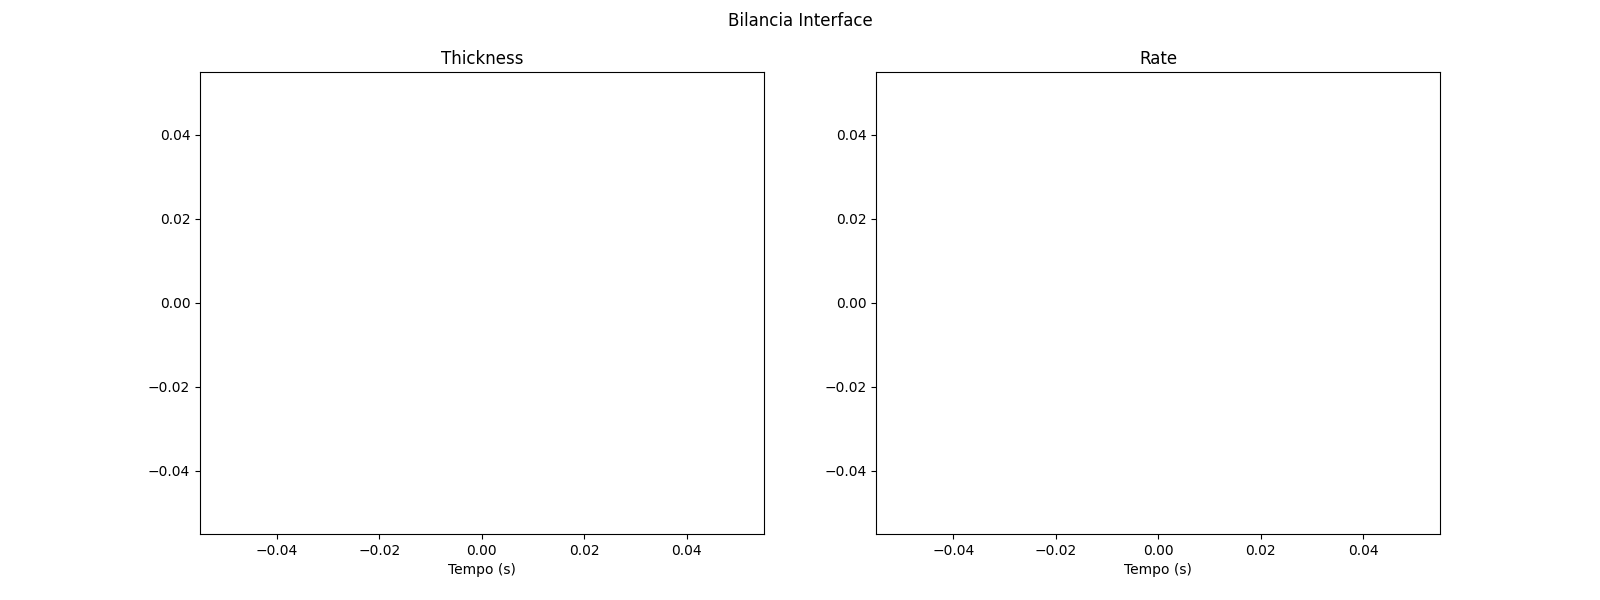

In [32]:
class BilanciaInterface(BaseInterface):
    def __init__(self, port=None):
        super().__init__()

        self.bilancia = None
        self.ports = list_ports.comports()
        self.selected_port = port

        self.thickness_data = []
        self.rate_data = []

        self.widgets["connect_btn"] = widgets.Button(description="Connect Bilancia")
        self.widgets["disconnect_btn"] = widgets.Button(description="Disconnect Bilancia")

        self._init_plot(
            suptitle="Bilancia Interface",
            ncols=2,
            nrows=1,
            plot_types=[['line', 'line']],
            plot_titles=[['Thickness', 'Rate']],
            xlabels=[['Tempo (s)', 'Tempo (s)']],
            ylabels=[['','']]
        )

        self.widgets["connect_btn"].on_click(lambda _: self.on_connect_btn())
        self.widgets["disconnect_btn"].on_click(lambda _: self.on_disconnect_btn())
        self.widgets["port_select"] = widgets.Dropdown(options=[(port.device, port.device) for port in self.ports], description="Port:")
        self.widgets["port_select"].observe(lambda change: setattr(self, "selected_port", change['new']), names='value')

        self.show()
    
    def show(self):
        display(self.output)
        display(widgets.HBox([self.widgets["connect_btn"], self.widgets["disconnect_btn"], self.widgets["port_select"]]))
        display(self.fig.canvas)
    
    def on_connect_btn(self):
        if self.selected_port is None:
            if len(self.ports) == 0:
                with self.output:
                    print("No serial ports found.")
                return
            else:
                self.selected_port = self.ports[0].device
        
        try:
            self.bilancia = Bilancia(self.selected_port)
            with self.output:
                print(f"Connected to bilancia on port {self.selected_port}")
        except Exception as e:
            with self.output:
                print(f"Failed to connect to bilancia: {e}")
            self.bilancia = None
        
        self.bilancia.start_continuous_read()
        self._start_update_plot(interval=100)
    
    def on_disconnect_btn(self):
        if self.bilancia is not None:
            self.bilancia.stop_continuous_read()
            self.bilancia.close()
            self.bilancia = None
            with self.output:
                print("Bilancia disconnected.")
        else:
            with self.output:
                print("No bilancia to disconnect.")

        self._stop_update_plot()
    
    def _update_plot(self):
        if self.bilancia is None:
            with self.output:
                print("No bilancia connected.")
                self._stop_update_plot()
            return
        
        data = self.bilancia.get_latest_data()

        if data is None:
            return
        
        try:
            (spessore, r), timestamp = data
            spessore = float(spessore)
            r = float(r)
            timestamp = float(timestamp)

            self.thickness_data.append(spessore)
            self.rate_data.append(r)

            self.artists[0, 0].set_data(self.thickness_data)
            self.artists[0, 1].set_data(self.rate_data)

            self.axes[0, 0].relim()
            self.axes[0, 0].autoscale_view()

            self.axes[0, 1].relim()
            self.axes[0, 1].autoscale_view()

            self.fig.canvas.draw_idle()
        
        except (TypeError, ValueError):
            # Scarta campione corrotto, non uccidere l'update loop
            with self.output:
                print("Dati corrotti ricevuti, scartando campione")
            return

bilancia_interface = BilanciaInterface()